# Ajuste de Hiperparâmetros — Regressão Logística

Este notebook busca os hiperparâmetros otimizados para o modelo de Regressão Logística  
usando `GridSearchCV` com validação cruzada estratificada no conjunto de treino balanceado pelo SMOTE.

### Etapas
1. Importações e configuração  
2. Carregar dados processados  
3. Definir o espaço de busca  
4. Grid search com validação cruzada  
5. Avaliar o melhor modelo no conjunto de teste  
6. Comparar modelo base vs. ajustado  
7. Ajuste de threshold no melhor modelo  
8. Resumo  


---
## 1. Importações e Configuração

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13, 'figure.dpi': 100})
pd.set_option('display.float_format', '{:.4f}'.format)

# -- Project root resolution -------------------------------------------------
def find_project_root(marker: str = 'requirements.txt') -> Path:
    for candidate in [Path.cwd()] + list(Path.cwd().parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (missing '{marker}').")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f'Project root : {PROJECT_ROOT}')
print('Imports complete.')

Project root : /Users/usuario/Desktop/logistic regression
Imports complete.


---
## 2. Carregar Dados Processados

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print('Data loaded.')
print(f'  X_train : {X_train.shape}  |  class 0: {(y_train==0).sum()}  class 1: {(y_train==1).sum()}')
print(f'  X_test  : {X_test.shape}   |  class 0: {(y_test==0).sum()}   class 1: {(y_test==1).sum()}')

Data loaded.
  X_train : (1870, 13)  |  class 0: 935  class 1: 935
  X_test  : (240, 13)   |  class 0: 234   class 1: 6


---
## 3. Definir o Espaço de Busca

Os principais hiperparâmetros da Regressão Logística são:

| Parâmetro | Descrição |
|---|---|
| `C` | Inverso da força de regularização — valores menores = regularização mais forte |
| `penalty` | Tipo de regularização — `l1` produz modelos esparsos, `l2` reduz todos os coeficientes |
| `solver` | Algoritmo de otimização — deve ser compatível com a penalidade escolhida |

Compatibilidade dos solvers:
- penalidade `l1` → `liblinear` ou `saga`
- penalidade `l2` → todos os solvers (`lbfgs`, `liblinear`, `saga`)
- `elasticnet` → apenas `saga` (requer `l1_ratio`)

In [3]:
param_grid = [
    # L2 regularization — tested with lbfgs and liblinear
    {
        'penalty' : ['l2'],
        'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
        'solver'  : ['lbfgs', 'liblinear'],
    },
    # L1 regularization — sparse solution, only compatible with liblinear / saga
    {
        'penalty' : ['l1'],
        'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
        'solver'  : ['liblinear', 'saga'],
    },
]

total_combos = sum(
    len(p['C']) * len(p['solver']) for p in param_grid
)
print(f'Total parameter combinations : {total_combos}')
print('Cross-validation strategy    : StratifiedKFold (5 folds)')
print(f'Total fits                   : {total_combos * 5}')

Total parameter combinations : 24
Cross-validation strategy    : StratifiedKFold (5 folds)
Total fits                   : 120


---
## 4. Grid Search com Validação Cruzada

O `StratifiedKFold` preserva a proporção das classes em cada fold.  
A métrica de pontuação é `roc_auc` — mais robusta que a acurácia para datasets desbalanceados.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,         # use all available CPU cores
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print(f'\nBest parameters  : {grid_search.best_params_}')
print(f'Best CV ROC-AUC  : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best parameters  : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC  : 0.9918


In [5]:
# Full cross-validation results sorted by mean test score
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    [['param_C', 'param_penalty', 'param_solver',
      'mean_test_score', 'std_test_score', 'mean_train_score']]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
)
cv_results.columns = ['C', 'penalty', 'solver', 'CV ROC-AUC (mean)', 'CV ROC-AUC (std)', 'Train ROC-AUC']

print('Top 10 parameter combinations:')
display(cv_results.head(10))

Top 10 parameter combinations:


,C,penalty,solver,CV ROC-AUC (mean),CV ROC-AUC (std),Train ROC-AUC
0,0.1000,l2,lbfgs,0.9918,0.0036,0.9930
1,0.1000,l1,saga,0.9917,0.0033,0.9923
2,0.0100,l2,lbfgs,0.9913,0.0029,0.9919
3,1.0000,l2,lbfgs,0.9913,0.0046,0.9932
4,0.1000,l1,liblinear,0.9912,0.0032,0.9918
5,1.0000,l1,liblinear,0.9911,0.0049,0.9932
6,1.0000,l1,saga,0.9910,0.0048,0.9933
7,1.0000,l2,liblinear,0.9908,0.0048,0.9928
8,10.0000,l2,liblinear,0.9908,0.0053,0.9931
9,10.0000,l2,lbfgs,0.9907,0.0052,0.9932


---
## 5. Avaliar o Melhor Modelo no Conjunto de Teste

In [6]:
best_model = grid_search.best_estimator_
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Find best threshold for F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_tuned >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

y_pred_tuned = (y_prob_tuned >= best_threshold).astype(int)

roc_auc_tuned  = roc_auc_score(y_test, y_prob_tuned)
avg_prec_tuned = average_precision_score(y_test, y_prob_tuned)

print(f'Best model parameters : {grid_search.best_params_}')
print(f'ROC-AUC               : {roc_auc_tuned:.4f}')
print(f'Average Precision     : {avg_prec_tuned:.4f}')
print(f'Best F1 Score         : {best_f1:.4f}  (threshold = {best_threshold:.2f})')
print()
print(classification_report(
    y_test, y_pred_tuned,
    target_names=['No Depression', 'Depression'],
    zero_division=0,
))

Best model parameters : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
ROC-AUC               : 0.9936
Average Precision     : 0.8626
Best F1 Score         : 0.7692  (threshold = 0.69)

               precision    recall  f1-score   support

No Depression       1.00      0.99      0.99       234
   Depression       0.71      0.83      0.77         6

     accuracy                           0.99       240
    macro avg       0.85      0.91      0.88       240
 weighted avg       0.99      0.99      0.99       240



---
## 6. Comparação: Modelo Base vs. Modelo Ajustado

Model Comparison:


,Model,ROC-AUC,Avg Precision,Best F1
0,"Baseline (C=1, l2, lbfgs)",0.9922,0.8333,0.7273
1,"Tuned ({'C': 0.1, 'penalty': 'l2', 'solver': '...",0.9936,0.8626,0.7692


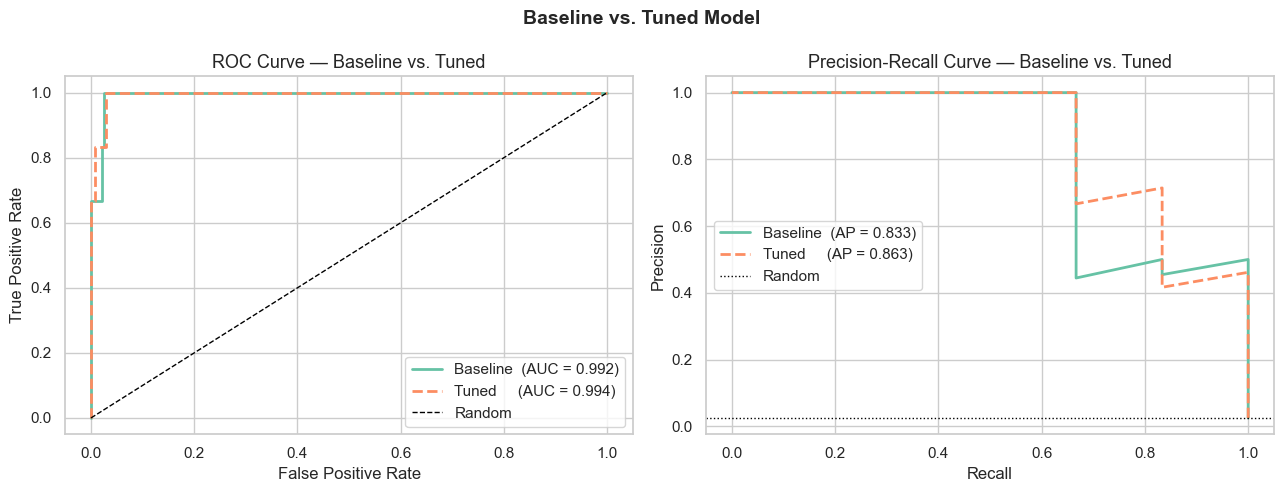

In [7]:
# Baseline model (from 03_model.ipynb)
baseline = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    solver='lbfgs', random_state=RANDOM_STATE,
)
baseline.fit(X_train, y_train)
y_prob_base = baseline.predict_proba(X_test)[:, 1]

f1_base_scores = [f1_score(y_test, (y_prob_base >= t).astype(int), zero_division=0) for t in thresholds]
best_f1_base   = max(f1_base_scores)

# Comparison table
comparison = pd.DataFrame({
    'Model'            : ['Baseline (C=1, l2, lbfgs)', f'Tuned ({grid_search.best_params_})'],
    'ROC-AUC'          : [roc_auc_score(y_test, y_prob_base), roc_auc_tuned],
    'Avg Precision'    : [average_precision_score(y_test, y_prob_base), avg_prec_tuned],
    'Best F1'          : [best_f1_base, best_f1],
})
print('Model Comparison:')
display(comparison)

# ROC curves side by side
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
prec_b, rec_b, _ = precision_recall_curve(y_test, y_prob_base)
prec_t, rec_t, _ = precision_recall_curve(y_test, y_prob_tuned)

PALETTE = sns.color_palette('Set2')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_b, tpr_b, color=PALETTE[0], lw=2,
             label=f'Baseline  (AUC = {roc_auc_score(y_test, y_prob_base):.3f})')
axes[0].plot(fpr_t, tpr_t, color=PALETTE[1], lw=2, linestyle='--',
             label=f'Tuned     (AUC = {roc_auc_tuned:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline vs. Tuned')
axes[0].legend()

# Precision-Recall
baseline_ap = average_precision_score(y_test, y_prob_base)
axes[1].plot(rec_b, prec_b, color=PALETTE[0], lw=2,
             label=f'Baseline  (AP = {baseline_ap:.3f})')
axes[1].plot(rec_t, prec_t, color=PALETTE[1], lw=2, linestyle='--',
             label=f'Tuned     (AP = {avg_prec_tuned:.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle=':', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Baseline vs. Tuned')
axes[1].legend()

plt.suptitle('Baseline vs. Tuned Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()

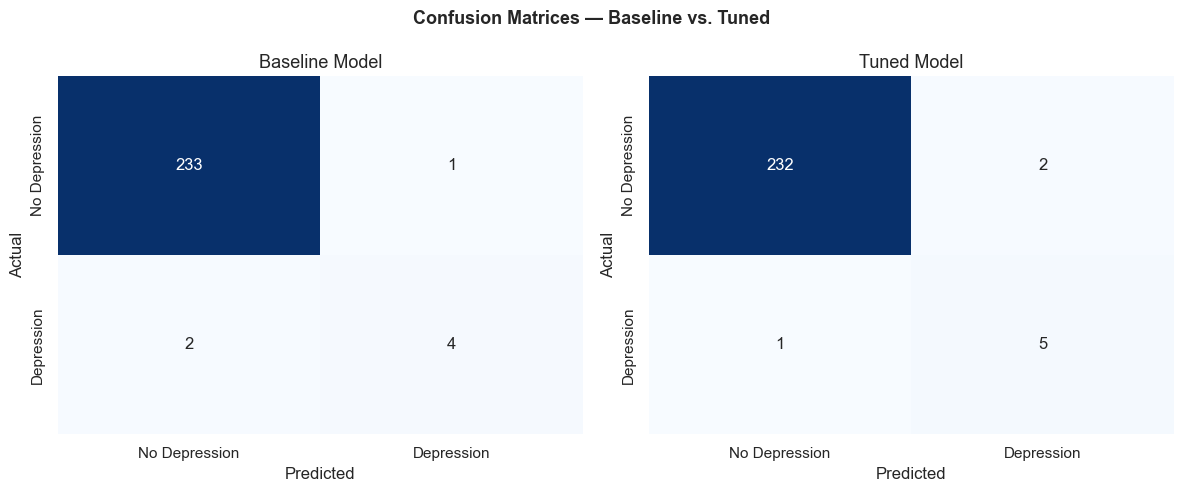

In [8]:
y_pred_base_best = (y_prob_base >= thresholds[np.argmax(f1_base_scores)]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_base_best, y_pred_tuned],
    ['Baseline Model', 'Tuned Model'],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Depression', 'Depression'],
        yticklabels=['No Depression', 'Depression'],
        cbar=False,
    )
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Baseline vs. Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_cm_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()

---
## 7. Resumo

In [9]:
bp = grid_search.best_params_

print('=' * 60)
print('        HYPERPARAMETER TUNING SUMMARY')
print('=' * 60)
print(f'  Search strategy  : GridSearchCV (5-fold StratifiedKFold)')
print(f'  Scoring metric   : ROC-AUC')
print(f'  Combinations     : {len(grid_search.cv_results_["params"])}')
print()
print(f'  Best parameters  :')
for k, v in bp.items():
    print(f'    {k:<12} : {v}')
print(f'  Best CV AUC      : {grid_search.best_score_:.4f}')
print()
print('  Test set performance:')
print(f'    ROC-AUC           : {roc_auc_tuned:.4f}  (baseline: {roc_auc_score(y_test, y_prob_base):.4f})')
print(f'    Average Precision : {avg_prec_tuned:.4f}  (baseline: {average_precision_score(y_test, y_prob_base):.4f})')
print(f'    Best F1           : {best_f1:.4f}  (baseline: {best_f1_base:.4f})')
print('=' * 60)

        HYPERPARAMETER TUNING SUMMARY
  Search strategy  : GridSearchCV (5-fold StratifiedKFold)
  Scoring metric   : ROC-AUC
  Combinations     : 24

  Best parameters  :
    C            : 0.1
    penalty      : l2
    solver       : lbfgs
  Best CV AUC      : 0.9918

  Test set performance:
    ROC-AUC           : 0.9936  (baseline: 0.9922)
    Average Precision : 0.8626  (baseline: 0.8333)
    Best F1           : 0.7692  (baseline: 0.7273)
